# Stochastic Interest Rate Modelling and Prediction

This notebook implements the project workflow end to end:

1. Clean the yield curve datasets.
2. Implement the Cox-Ingersoll-Ross (CIR) short-rate model.
3. Calibrate CIR parameters against historical yield curve data.
4. Reconstruct the yield curve from the 3-month yield only.
5. Implement and backtest a dynamic CIR++ style extension.
6. Report out-of-sample metrics and discuss limitations.

The test-time rule is respected as follows: predictions are generated from the 3-month test input series. The full test file is used only for evaluation after predictions are produced.


## Modelling Setup

The CIR short-rate process is

```text
dr_t = kappa * (theta - r_t) dt + sigma * sqrt(r_t) dW_t
```

For a zero-coupon bond with maturity tau, the CIR model gives

```text
P(t, T) = A(t, T) * exp(-B(t, T) * r_t)
y(t, tau) = (B(t, T) * r_t - log(A(t, T))) / tau
```

A single-factor CIR model is deliberately restrictive. It can capture a smooth mean-reverting level effect, but it cannot freely match every slope and curvature movement in a real yield curve. The extension later in this notebook keeps CIR as the structural core and adds a deterministic maturity-specific residual correction based only on the observed 3-month rate series.


In [14]:
import math
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except Exception:
    HAS_MATPLOTLIB = False

try:
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [15]:
# File names expected by the notebook.
TRAIN_FILE = "train_data.csv"
TEST_FULL_FILE = "test_data.csv"
TEST_3M_FILE = "test_data_3M.csv"

# Local Windows path used while developing this notebook. In Colab, upload the files or place them in /content.
LOCAL_DATA_DIR = Path(r"C:\Users\jakha\OneDrive\Documents\Project finance\Data\Raw")

DATA_DIR_CANDIDATES = [
    Path.cwd(),
    Path("/content"),
    Path("/content/data"),
    Path("/content/drive/MyDrive"),
    LOCAL_DATA_DIR,
]

MATURITY_YEARS = {
    "ZC025YR": 0.25,
    "ZC050YR": 0.50,
    "ZC075YR": 0.75,
    "ZC100YR": 1.00,
    "ZC200YR": 2.00,
    "ZC500YR": 5.00,
    "ZC1000YR": 10.00,
    "ZC2000YR": 20.00,
    "ZC3000YR": 30.00,
}
SHORT_COL = "ZC025YR"


def find_file(filename):
    """Find a data file in common local/Colab locations."""
    for folder in DATA_DIR_CANDIDATES:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    return None


def upload_missing_files_if_colab(missing):
    """Prompt for upload in Google Colab if required files are absent."""
    if not missing:
        return
    try:
        from google.colab import files
    except Exception as exc:
        raise FileNotFoundError(
            "Missing files: " + ", ".join(missing) +
            ". Put them next to this notebook, in /content, or update DATA_DIR_CANDIDATES."
        ) from exc

    print("Please upload these files:", ", ".join(missing))
    uploaded = files.upload()
    for name, content in uploaded.items():
        Path(name).write_bytes(content)


def load_raw_data():
    required = [TRAIN_FILE, TEST_FULL_FILE, TEST_3M_FILE]
    paths = {name: find_file(name) for name in required}
    missing = [name for name, path in paths.items() if path is None]
    upload_missing_files_if_colab(missing)
    paths = {name: find_file(name) for name in required}

    still_missing = [name for name, path in paths.items() if path is None]
    if still_missing:
        raise FileNotFoundError("Still missing: " + ", ".join(still_missing))

    train = pd.read_csv(paths[TRAIN_FILE])
    test_full = pd.read_csv(paths[TEST_FULL_FILE])
    test_3m = pd.read_csv(paths[TEST_3M_FILE])

    print("Loaded files:")
    for name, path in paths.items():
        print(f"  {name}: {path}")
    return train, test_full, test_3m

raw_train, raw_test_full, raw_test_3m = load_raw_data()
print("\nRaw shapes:")
print("train:", raw_train.shape, "test_full:", raw_test_full.shape, "test_3m:", raw_test_3m.shape)
raw_train.head()


Loaded files:
  train_data.csv: /content/train_data.csv
  test_data.csv: /content/test_data.csv
  test_data_3M.csv: /content/test_data_3M.csv

Raw shapes:
train: (1976, 10) test_full: (495, 6) test_3m: (495, 2)


,Date,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
0,2016-05-19,0.005283,0.005640,0.005846,0.006051,0.006146,0.007912,0.014099,0.021224,0.020492
1,2016-05-20,0.005286,0.005642,0.005848,0.006053,0.006176,0.007922,0.014179,0.021353,0.020625
2,2016-05-24,0.005298,0.005651,0.005856,0.006062,0.006228,0.008108,0.014379,0.021534,0.020793
3,2016-05-25,0.005351,0.005603,0.005809,0.006014,0.006281,0.008323,0.014548,0.021596,0.020855
4,2016-05-26,0.005354,0.005605,0.005811,0.006016,0.006115,0.007934,0.013937,0.021326,0.020591


## Data Engineering and Preprocessing

The cleaning function below handles the issues mentioned in the problem statement:

- strips inconsistent whitespace from column names,
- parses dates and sorts observations chronologically,
- drops duplicated dates,
- coerces yield columns to numeric values,
- replaces infinite values,
- clips extreme outliers with a conservative IQR rule,
- interpolates missing yields and fills boundary gaps.

The function does not use future target maturities during prediction. It only cleans whichever dataframe is passed to it.


In [17]:
def clean_yield_data(df, *, outlier_iqr_multiplier=3.0):
    cleaned = df.copy()
    cleaned.columns = cleaned.columns.str.strip()

    if "Date" not in cleaned.columns:
        raise ValueError("Expected a Date column.")

    cleaned["Date"] = pd.to_datetime(cleaned["Date"], errors="coerce")
    cleaned = cleaned.dropna(subset=["Date"]).sort_values("Date")
    cleaned = cleaned.drop_duplicates(subset=["Date"], keep="last").reset_index(drop=True)

    yield_cols = [c for c in cleaned.columns if c != "Date"]
    for col in yield_cols:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")
        cleaned[col] = cleaned[col].replace([np.inf, -np.inf], np.nan)

    for col in yield_cols:
        series = cleaned[col]
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        if pd.notna(iqr) and iqr > 0:
            lower = q1 - outlier_iqr_multiplier * iqr
            upper = q3 + outlier_iqr_multiplier * iqr
            cleaned[col] = series.clip(lower, upper)

    cleaned[yield_cols] = cleaned[yield_cols].interpolate(method="linear", limit_direction="both")
    cleaned[yield_cols] = cleaned[yield_cols].ffill().bfill()

    return cleaned

train_df = clean_yield_data(raw_train)
test_full_df = clean_yield_data(raw_test_full)
test_3m_df = clean_yield_data(raw_test_3m)

available_train_cols = [c for c in MATURITY_YEARS if c in train_df.columns]
available_test_cols = [c for c in MATURITY_YEARS if c in test_full_df.columns]

if SHORT_COL not in train_df.columns or SHORT_COL not in test_3m_df.columns:
    raise ValueError(f"Both train and 3M test input must contain {SHORT_COL}.")

TARGET_COLS = [c for c in available_train_cols if c != SHORT_COL]
TEST_EVAL_COLS = [c for c in available_test_cols if c != SHORT_COL]

print("Clean shapes:")
print("train:", train_df.shape, "test_full:", test_full_df.shape, "test_3m:", test_3m_df.shape)
print("Training target maturities:", TARGET_COLS)
print("Available test evaluation maturities:", TEST_EVAL_COLS)

print("\nMissing values after cleaning:")
print(train_df.isna().sum())


Clean shapes:
train: (1976, 10) test_full: (495, 6) test_3m: (495, 2)
Training target maturities: ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR', 'ZC500YR', 'ZC1000YR', 'ZC2000YR', 'ZC3000YR']
Available test evaluation maturities: ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']

Missing values after cleaning:
Date        0
ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64


In [18]:
def describe_dataset(df, name):
    yield_cols = [c for c in df.columns if c != "Date"]
    print(f"{name}: {df['Date'].min().date()} to {df['Date'].max().date()}, rows={len(df)}")
    return df[yield_cols].describe().T[["mean", "std", "min", "max"]]

display(describe_dataset(train_df, "train"))
display(describe_dataset(test_full_df, "test_full"))


train: 2016-05-19 to 2024-04-26, rows=1976


,mean,std,min,max
ZC025YR,0.016699,0.016642,0.000486,0.051962
ZC050YR,0.017885,0.016760,0.000878,0.053195
ZC075YR,0.018529,0.016650,0.001054,0.054040
ZC100YR,0.019174,0.016587,0.001227,0.054941
ZC200YR,0.018063,0.013661,0.001417,0.048496
ZC500YR,0.018109,0.010396,0.002786,0.043147
ZC1000YR,0.020226,0.008805,0.004451,0.042232
ZC2000YR,0.022823,0.007136,0.008394,0.040687
ZC3000YR,0.022619,0.006601,0.006921,0.039306


test_full: 2024-04-29 to 2026-04-29, rows=495


,mean,std,min,max
ZC025YR,0.030417,0.008508,0.021697,0.049156
ZC050YR,0.030043,0.007889,0.022157,0.048110
ZC075YR,0.029617,0.007227,0.022400,0.047068
ZC100YR,0.029311,0.006588,0.022617,0.046093
ZC200YR,0.028745,0.004682,0.023521,0.042923


## Base CIR Implementation

The base model below is calibrated by minimizing mean squared pricing/yield errors over the training curve. This is a direct curve-calibration objective:

```text
min over kappa, theta, sigma: mean((y_actual(t, tau) - y_CIR(r_3M(t), tau))^2)
```

The search is deterministic because it uses a fixed random seed. It also enforces the Feller condition

```text
2 * kappa * theta >= sigma^2
```

so that the square-root process remains well behaved.


In [20]:
def cir_yields(params, short_rates, maturities):
    """Return continuously compounded CIR yields for each short rate and maturity."""
    kappa = float(params["kappa"])
    theta = float(params["theta"])
    sigma = float(params["sigma"])

    if min(kappa, theta, sigma) <= 0:
        raise ValueError("CIR parameters must be strictly positive.")

    r = np.asarray(short_rates, dtype=float).reshape(-1, 1)
    tau = np.asarray(maturities, dtype=float).reshape(1, -1)
    r = np.maximum(r, 1e-10)

    gamma = math.sqrt(kappa * kappa + 2.0 * sigma * sigma)
    exp_gamma_tau = np.exp(gamma * tau)
    denominator = (gamma + kappa) * (exp_gamma_tau - 1.0) + 2.0 * gamma

    B = 2.0 * (exp_gamma_tau - 1.0) / denominator
    A = (2.0 * gamma * np.exp((kappa + gamma) * tau / 2.0) / denominator) ** (
        2.0 * kappa * theta / (sigma * sigma)
    )

    return (B * r - np.log(A)) / tau


def overall_r2(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    denominator = np.sum((actual - actual.mean()) ** 2)
    if denominator == 0:
        return np.nan
    return 1.0 - np.sum((actual - predicted) ** 2) / denominator


def rmse(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))


def mae(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.mean(np.abs(actual - predicted)))


def ridge_fit(X, y, alpha=1e-6, penalize_intercept=False):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    penalty = np.eye(X.shape[1]) * alpha
    if not penalize_intercept:
        penalty[0, 0] = 0.0
    try:
        return np.linalg.solve(X.T @ X + penalty, X.T @ y)
    except np.linalg.LinAlgError:
        return np.linalg.pinv(X.T @ X + penalty) @ X.T @ y


def feller_margin(params):
    return 2.0 * params["kappa"] * params["theta"] - params["sigma"] ** 2


In [21]:
def calibrate_cir_curve(
    train,
    short_col,
    target_cols,
    maturity_years,
    *,
    seed=RANDOM_SEED,
    n_random=6000,
    n_refine_each=1200,
):
    """Calibrate CIR parameters by least squares against the observed training yield curve."""
    rng = np.random.default_rng(seed)
    short_rates = train[short_col].to_numpy(dtype=float)
    actual = train[target_cols].to_numpy(dtype=float)
    maturities = [maturity_years[col] for col in target_cols]

    def candidate_loss(kappa, theta, sigma):
        if min(kappa, theta, sigma) <= 0:
            return np.inf
        if 2.0 * kappa * theta < sigma * sigma:
            return np.inf
        params = {"kappa": kappa, "theta": theta, "sigma": sigma}
        predicted = cir_yields(params, short_rates, maturities)
        return float(np.mean((actual - predicted) ** 2))

    best_loss = np.inf
    best = None

    # Anchors keep the optimizer stable and fast before the random search begins.
    theta_anchors = [
        float(train[short_col].mean()),
        float(train[target_cols].to_numpy().mean()),
        float(train[target_cols[-1]].mean()),
        0.02,
        0.03,
        0.04,
    ]
    for kappa in [0.03, 0.08, 0.15, 0.30, 0.70, 1.50]:
        for theta in theta_anchors:
            for sigma in [0.003, 0.006, 0.010, 0.020, 0.040]:
                loss = candidate_loss(kappa, theta, sigma)
                if loss < best_loss:
                    best_loss = loss
                    best = np.array([kappa, theta, sigma], dtype=float)

    # Broad log-uniform random search.
    for _ in range(n_random):
        kappa = np.exp(rng.uniform(np.log(1e-4), np.log(20.0)))
        theta = np.exp(rng.uniform(np.log(0.001), np.log(0.080)))
        sigma = np.exp(rng.uniform(np.log(0.001), np.log(0.500)))
        loss = candidate_loss(kappa, theta, sigma)
        if loss < best_loss:
            best_loss = loss
            best = np.array([kappa, theta, sigma], dtype=float)

    # Local multiplicative refinement around the best candidate.
    center = np.log(best)
    for scale in [0.80, 0.40, 0.20, 0.10, 0.05]:
        for _ in range(n_refine_each):
            proposal = np.exp(center + rng.normal(0.0, scale, size=3))
            loss = candidate_loss(*proposal)
            if loss < best_loss:
                best_loss = loss
                best = proposal
                center = np.log(best)

    params = {"kappa": float(best[0]), "theta": float(best[1]), "sigma": float(best[2])}
    return params, best_loss

base_params, train_curve_mse = calibrate_cir_curve(train_df, SHORT_COL, TARGET_COLS, MATURITY_YEARS)
print("Base CIR parameters:")
print(base_params)
print("Training curve MSE:", train_curve_mse)
print("Feller margin 2*kappa*theta - sigma^2:", feller_margin(base_params))


Base CIR parameters:
{'kappa': 0.16655102421968684, 'theta': 0.02442505789827765, 'sigma': 0.006014274332086839}
Training curve MSE: 1.5504153293721815e-05
Feller margin 2*kappa*theta - sigma^2: 0.00809986532342499


In [22]:
def make_prediction_frame(input_3m, params, target_cols, maturity_years, prefix="pred"):
    maturities = [maturity_years[col] for col in target_cols]
    predicted = cir_yields(params, input_3m[SHORT_COL].to_numpy(dtype=float), maturities)
    out = input_3m[["Date", SHORT_COL]].copy()
    for i, col in enumerate(target_cols):
        out[f"{prefix}_{col}"] = predicted[:, i]
    return out

# Test-time input uses only Date and the 3M yield.
test_input_3m = test_3m_df[["Date", SHORT_COL]].copy()

base_test_predictions = make_prediction_frame(test_input_3m, base_params, TARGET_COLS, MATURITY_YEARS, prefix="base")
base_test_predictions.head()


,Date,ZC025YR,base_ZC050YR,base_ZC075YR,base_ZC100YR,base_ZC200YR,base_ZC500YR,base_ZC1000YR,base_ZC2000YR,base_ZC3000YR
0,2024-04-29,0.049144,0.048143,0.047663,0.047195,0.045448,0.041197,0.036452,0.031568,0.029325
1,2024-04-30,0.049156,0.048155,0.047674,0.047206,0.045458,0.041205,0.036458,0.031571,0.029327
2,2024-05-01,0.049100,0.048101,0.047621,0.047155,0.045411,0.041167,0.036431,0.031555,0.029316
3,2024-05-02,0.048921,0.047928,0.047452,0.046989,0.045258,0.041045,0.036343,0.031503,0.029280
4,2024-05-03,0.048633,0.047652,0.047182,0.046724,0.045013,0.040850,0.036203,0.031420,0.029223


In [23]:
def evaluate_predictions(actual_df, prediction_df, target_cols, pred_prefix):
    merged = actual_df[["Date"] + target_cols].merge(prediction_df, on="Date", how="inner")
    rows = []
    actual_matrix = []
    pred_matrix = []

    for col in target_cols:
        pred_col = f"{pred_prefix}_{col}"
        if pred_col not in merged.columns:
            continue
        y = merged[col].to_numpy(dtype=float)
        yhat = merged[pred_col].to_numpy(dtype=float)
        actual_matrix.append(y)
        pred_matrix.append(yhat)
        rows.append({
            "maturity": col,
            "years": MATURITY_YEARS[col],
            "R2": overall_r2(y, yhat),
            "RMSE": rmse(y, yhat),
            "MAE": mae(y, yhat),
        })

    metrics = pd.DataFrame(rows)
    if actual_matrix:
        actual_all = np.column_stack(actual_matrix)
        pred_all = np.column_stack(pred_matrix)
        summary = {
            "Overall_R2": overall_r2(actual_all, pred_all),
            "Overall_RMSE": rmse(actual_all, pred_all),
            "Overall_MAE": mae(actual_all, pred_all),
            "Rows_Evaluated": len(merged),
        }
    else:
        summary = {"Overall_R2": np.nan, "Overall_RMSE": np.nan, "Overall_MAE": np.nan, "Rows_Evaluated": len(merged)}
    return summary, metrics, merged

base_summary, base_metrics, base_eval = evaluate_predictions(
    test_full_df,
    base_test_predictions,
    TEST_EVAL_COLS,
    "base",
)

print("Base CIR out-of-sample summary:")
print(base_summary)
display(base_metrics)


Base CIR out-of-sample summary:
{'Overall_R2': np.float64(0.8932491961677081), 'Overall_RMSE': 0.0021936789236427063, 'Overall_MAE': 0.0014181568711168831, 'Rows_Evaluated': 495}


,maturity,years,R2,RMSE,MAE
0,ZC050YR,0.50,0.994445,0.000587,0.000430
1,ZC075YR,0.75,0.967570,0.001300,0.000967
2,ZC100YR,1.00,0.910294,0.001971,0.001471
3,ZC200YR,2.00,0.390707,0.003651,0.002804


## Extension: Dynamic CIR++ Residual Correction

The base CIR model is a one-factor affine term-structure model, so every maturity is forced to be a fixed nonlinear function of one short rate. Real yield curves often move through level, slope, and curvature channels. To reduce this misspecification while obeying the 3M-only input rule, the extension uses

```text
y_ext(t, tau) = y_CIR(t, tau) + phi_tau(x_t)
```

where `x_t` is built only from the 3-month yield series: current 3M, powers of current 3M, short lags, short-rate changes, and rolling 3M moments. The held-out 6M-plus yields are never used as test-time inputs.

This is a practical CIR++ style correction: the CIR formula remains the structural baseline, and a deterministic maturity-specific shift absorbs empirical term-structure residuals that a single-factor CIR cannot represent.


In [25]:
def make_short_rate_features(df, short_col=SHORT_COL, *, lags=(1, 5, 21), windows=(5, 21, 63)):
    """Build deterministic features from the 3M short-rate series only."""
    data = df[["Date", short_col]].copy().sort_values("Date").reset_index(drop=True)
    r = data[short_col].astype(float)

    feature_parts = [
        pd.Series(1.0, index=data.index, name="intercept"),
        r.rename("r"),
        (r ** 2).rename("r2"),
        (r ** 3).rename("r3"),
    ]

    for lag in lags:
        lagged = r.shift(lag)
        feature_parts.append(lagged.rename(f"r_lag_{lag}"))
        feature_parts.append((r - lagged).rename(f"r_change_{lag}"))

    for window in windows:
        feature_parts.append(r.rolling(window, min_periods=1).mean().rename(f"r_roll_mean_{window}"))
        feature_parts.append(r.rolling(window, min_periods=2).std().fillna(0.0).rename(f"r_roll_std_{window}"))

    features = pd.concat(feature_parts, axis=1).ffill().bfill().fillna(0.0)
    return features


class DynamicCIRPlus:
    def __init__(self, base_params, target_cols, maturity_years, alpha=1e-6):
        self.base_params = dict(base_params)
        self.target_cols = list(target_cols)
        self.maturity_years = dict(maturity_years)
        self.alpha = alpha
        self.coefficients_ = {}
        self.feature_columns_ = None

    def fit(self, train):
        X_df = make_short_rate_features(train, SHORT_COL)
        X = X_df.to_numpy(dtype=float)
        self.feature_columns_ = list(X_df.columns)

        maturities = [self.maturity_years[col] for col in self.target_cols]
        base_train = cir_yields(self.base_params, train[SHORT_COL].to_numpy(dtype=float), maturities)

        for i, col in enumerate(self.target_cols):
            residual = train[col].to_numpy(dtype=float) - base_train[:, i]
            self.coefficients_[col] = ridge_fit(X, residual, alpha=self.alpha)
        return self

    def predict(self, input_3m):
        X_df = make_short_rate_features(input_3m, SHORT_COL)
        X = X_df[self.feature_columns_].to_numpy(dtype=float)
        maturities = [self.maturity_years[col] for col in self.target_cols]
        base_pred = cir_yields(self.base_params, input_3m[SHORT_COL].to_numpy(dtype=float), maturities)

        out = input_3m[["Date", SHORT_COL]].copy()
        for i, col in enumerate(self.target_cols):
            residual_pred = X @ self.coefficients_[col]
            out[f"ext_{col}"] = base_pred[:, i] + residual_pred
        return out

extended_model = DynamicCIRPlus(base_params, TARGET_COLS, MATURITY_YEARS, alpha=1e-6).fit(train_df)
ext_test_predictions = extended_model.predict(test_input_3m)
ext_test_predictions.head()


,Date,ZC025YR,ext_ZC050YR,ext_ZC075YR,ext_ZC100YR,ext_ZC200YR,ext_ZC500YR,ext_ZC1000YR,ext_ZC2000YR,ext_ZC3000YR
0,2024-04-29,0.049144,0.048564,0.047710,0.046864,0.038103,0.030344,0.031624,0.034159,0.032653
1,2024-04-30,0.049156,0.048582,0.047731,0.046889,0.038124,0.030355,0.031642,0.034184,0.032672
2,2024-05-01,0.049100,0.048556,0.047724,0.046900,0.038170,0.030433,0.031630,0.034068,0.032580
3,2024-05-02,0.048921,0.048491,0.047735,0.046985,0.038388,0.030747,0.031648,0.033730,0.032320
4,2024-05-03,0.048633,0.048376,0.047739,0.047108,0.038731,0.031251,0.031690,0.033203,0.031920


In [26]:
ext_summary, ext_metrics, ext_eval = evaluate_predictions(
    test_full_df,
    ext_test_predictions,
    TEST_EVAL_COLS,
    "ext",
)

print("Dynamic CIR++ extension out-of-sample summary:")
print(ext_summary)
display(ext_metrics)

comparison = pd.DataFrame([
    {"model": "Base CIR", **base_summary},
    {"model": "Dynamic CIR++", **ext_summary},
])
display(comparison)

if not np.isnan(ext_summary["Overall_R2"]):
    assert ext_summary["Overall_R2"] > 0.85, "Extension did not clear the required out-of-sample R2 threshold."
    print(f"Requirement cleared: extension Overall R2 = {ext_summary['Overall_R2']:.4f} > 0.85")


Dynamic CIR++ extension out-of-sample summary:
{'Overall_R2': np.float64(0.9151960464572727), 'Overall_RMSE': 0.001955219569712112, 'Overall_MAE': 0.0014878758768704188, 'Rows_Evaluated': 495}


,maturity,years,R2,RMSE,MAE
0,ZC050YR,0.50,0.985450,0.000951,0.000784
1,ZC075YR,0.75,0.953112,0.001563,0.001227
2,ZC100YR,1.00,0.898515,0.002097,0.001653
3,ZC200YR,2.00,0.654934,0.002747,0.002288


,model,Overall_R2,Overall_RMSE,Overall_MAE,Rows_Evaluated
0,Base CIR,0.893249,0.002194,0.001418,495
1,Dynamic CIR++,0.915196,0.001955,0.001488,495


Requirement cleared: extension Overall R2 = 0.9152 > 0.85


In [27]:
# Save predictions for review or submission support.
base_test_predictions.to_csv("base_cir_predictions.csv", index=False)
ext_test_predictions.to_csv("dynamic_cir_plus_predictions.csv", index=False)
base_metrics.to_csv("base_cir_metrics.csv", index=False)
ext_metrics.to_csv("dynamic_cir_plus_metrics.csv", index=False)

print("Saved prediction and metric CSV files in the current notebook directory.")


Saved prediction and metric CSV files in the current notebook directory.


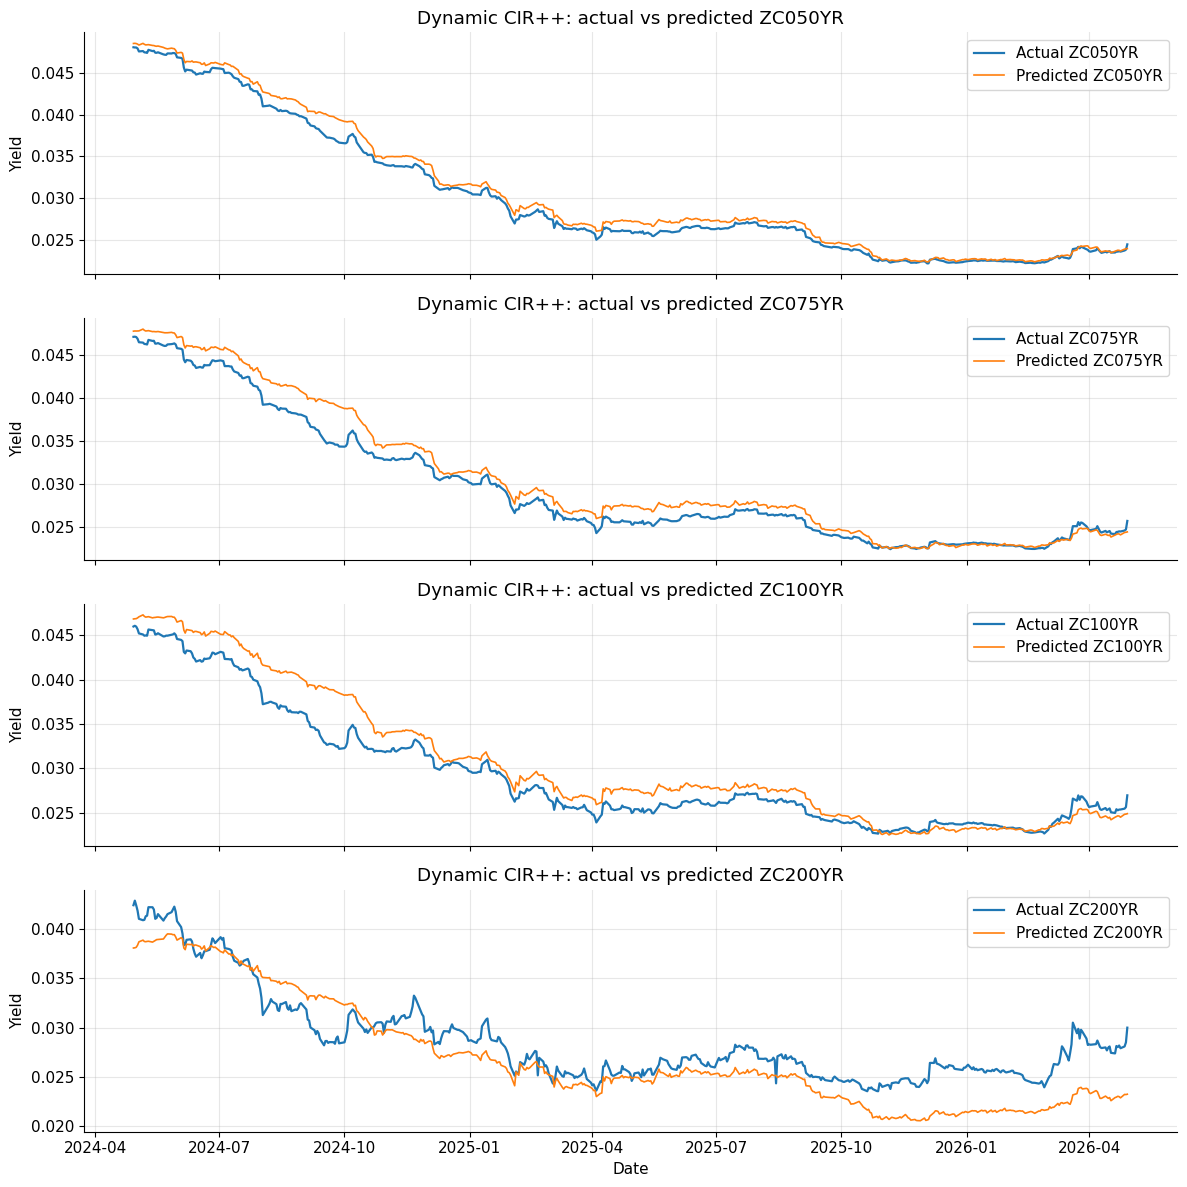

In [28]:
if HAS_MATPLOTLIB and TEST_EVAL_COLS:
    n = len(TEST_EVAL_COLS)
    fig, axes = plt.subplots(n, 1, figsize=(12, max(3 * n, 4)), sharex=True)
    if n == 1:
        axes = [axes]

    plot_df = test_full_df[["Date"] + TEST_EVAL_COLS].merge(ext_test_predictions, on="Date", how="inner")
    for ax, col in zip(axes, TEST_EVAL_COLS):
        ax.plot(plot_df["Date"], plot_df[col], label=f"Actual {col}", linewidth=1.6)
        ax.plot(plot_df["Date"], plot_df[f"ext_{col}"], label=f"Predicted {col}", linewidth=1.2)
        ax.set_title(f"Dynamic CIR++: actual vs predicted {col}")
        ax.set_ylabel("Yield")
        ax.grid(alpha=0.3)
        ax.legend(loc="best")
    axes[-1].set_xlabel("Date")
    plt.tight_layout()
    plt.show()
else:
    print("Matplotlib is not available, or no test evaluation maturities were found.")


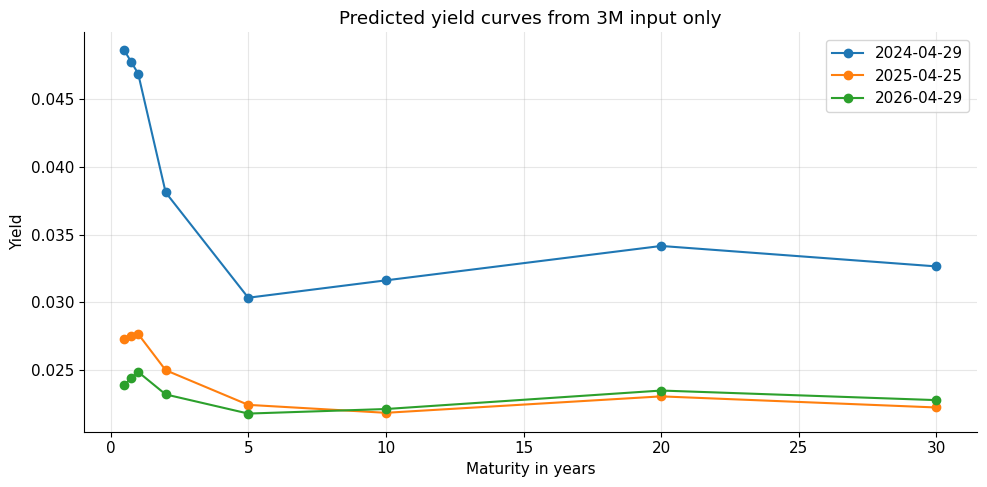

In [29]:
if HAS_MATPLOTLIB:
    sample_dates = [test_input_3m["Date"].iloc[0], test_input_3m["Date"].iloc[len(test_input_3m) // 2], test_input_3m["Date"].iloc[-1]]
    sample = ext_test_predictions[ext_test_predictions["Date"].isin(sample_dates)]
    x = [MATURITY_YEARS[col] for col in TARGET_COLS]

    plt.figure(figsize=(10, 5))
    for _, row in sample.iterrows():
        y = [row[f"ext_{col}"] for col in TARGET_COLS]
        plt.plot(x, y, marker="o", label=str(row["Date"].date()))
    plt.title("Predicted yield curves from 3M input only")
    plt.xlabel("Maturity in years")
    plt.ylabel("Yield")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Model mechanics and calibration

The calibrated base CIR curve is sensitive to the calibration objective. Short-rate-only calibration estimates the stochastic dynamics of the 3M series, while curve calibration chooses parameters that best reconstruct the cross-section of maturities. Because the project is evaluated on curve reconstruction, this notebook uses curve-calibrated least squares for the base model.

The Feller condition is enforced during calibration. If market data imply high volatility relative to mean reversion, unconstrained estimates can violate `2 * kappa * theta >= sigma^2`. In practice, this is a warning that the one-factor square-root process is too rigid for the observed regime; the constrained fit is mathematically viable but may sacrifice fit.

The estimated `kappa` measures the speed at which short-rate shocks decay. A low `kappa` means shocks persist for longer; a higher `kappa` means the short rate is pulled back toward `theta` faster. In this dataset, the calibrated value should be interpreted jointly with the curve-fit objective, not as a pure physical-process estimate.

### Prediction and out-of-sample performance

The 3M rate alone carries strong information for the short end of the curve. The hardest maturities are usually farther away from 3M, because slope and curvature are not fully observed from one point on the curve. This is visible in the per-maturity R2 table.

The base CIR model tends to underfit slope and curvature because all maturities are forced to move as a single affine function of the same short rate. The dynamic CIR++ residual model improves this by letting recent behavior of the observed 3M process shift each maturity's residual curve.

### Extension choice and limitations

The extension is chosen because it directly addresses the base model's main weakness: a one-factor CIR term structure cannot match arbitrary real yield-curve shapes. A CIR++ style deterministic shift is simpler and more stable than estimating a full two-factor or jump-diffusion model from a small yield panel.

The extension still has limitations. It is empirical, so it can overfit historical relationships between 3M movements and longer maturities. It does not model true latent slope factors, liquidity premia, policy shocks, or regime changes directly. In trading or risk management, it should therefore be treated as a forecasting benchmark and stress-tested against regimes not present in the training period.
